# **Deep learning project.**
---

# **Introduction.**

This project implements an image captioning system (a model that automatically generates a  description for a given image), by combining:
* A Convolutional Neural Network (CNN) for visual feature
extraction,
* A Recurrent Neural Network (LSTM) for sequence modeling.

The model is trained on the Flickr8k dataset, using paired image-caption data. Additionally, Explainable AI (XAI) is implemented at the end, via Grad-CAM heatmaps.


# **Data preparation.**

The Flickr8k dataset is stored in Google Drive, so to access it the drive is mounted within the Google Colab environment. This enables direct reading of image and annotation files required for training and evaluation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The required libraries for data processing, model construction, and visualization are imported. This implementation is based on TensorFlow and Keras, and MobileNetV2 is used as a pretrained feature extractor (convolutional neural network).


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Add
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

The Flickr8k dataset and corresponding caption annotations are loaded. The goal is to prepare paired image–text data for supervised image captioning training. Before proceeding with preprocessing and model construction, a subset of sample images is displayed to verify correct dataset loading and structure. All images are resized to 224×224 pixels, which corresponds to the input size required by MobileNetV2.

In [ ]:
IMAGE_DIR = "/content/drive/MyDrive/flicker8k/Images/"
CAPTION_FILE = "/content/drive/MyDrive/flicker8k/captions.txt"

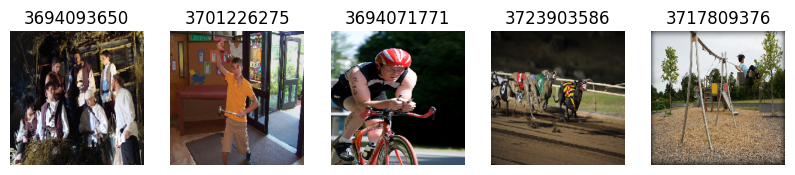

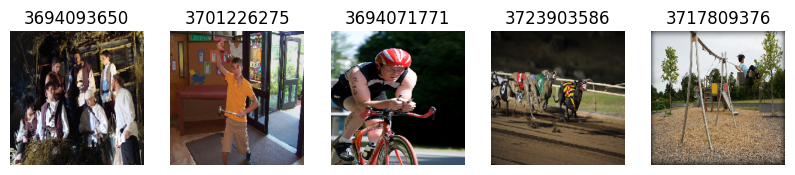

In [ ]:
sample_images = os.listdir(IMAGE_DIR)[:5]

plt.figure(figsize=(10,5))
for i, img_name in enumerate(sample_images):
    img = image.load_img(os.path.join(IMAGE_DIR, img_name), target_size=(224,224))
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name[:10])

plt.show()

Caption annotations are loaded from the Flickr8k caption file and paired with their corresponding image filenames. To reduce computational cost and training time, only a subset of the dataset (defined by *MAX_SAMPLES*) is used.

Each caption is augmented with special boundary tokens (*start* and *end*) to enable proper sequence modeling during training. These tokens allow the decoder to learn when to begin and when to stop generating a description.
The result of this step is a set of aligned image–caption pairs.


In [ ]:
MAX_SAMPLES = 8000 #change for quicker compilation

captions = []
image_names = []

with open(CAPTION_FILE, "r", encoding="utf-8") as f:
    next(f)
    for line in f.readlines()[:MAX_SAMPLES]:
        img_full, caption = line.strip().split(",", 1)
        img = img_full.split("#")[0]
        captions.append("start " + caption + " end")
        image_names.append(img)

A tokenizer is created to convert textual captions into sequences of integer indices, one per word.

First, the tokenizer is fitted on all captions, building a vocabulary of all unique words in the dataset.

Then, each caption is transformed into a sequence of integers representing the words.

To ensure consistent input size for the model, all sequences are padded to the same length, equal to the length of the longest caption.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)

sequences = tokenizer.texts_to_sequences(captions)
vocab_size = len(tokenizer.word_index) + 1

max_len = max(len(seq) for seq in sequences)
sequences = pad_sequences(sequences, maxlen=max_len)

After this step, we have:
* vocab_size: the total number of unique words in the dataset (plus one for padding),
* max_len: the maximum caption length.

# **The model.**

Model implements an image captioning pipeline that combines a CNN for extracting visual features with an LSTM for generating text. Image features are processed through a dense layer, and caption sequences are passed through an embedding layer and LSTM (long short-term memory). Their outputs are combined and fed to a dense-softmax layer to predict the next word.

First, a pre-trained MobileNetV2 processes each image into a fixed-length feature vector, while captions are tokenized, converted into sequences, and padded for consistent input.  

Then, during training, the network learns to map image features and partial captions to likely next words.

At the end, captions are generated iteratively from a starting token using temperature sampling until the end token is reached, producing readable descriptions.

---



## **Image feature extraction.**


A pre-trained MobileNetV2 network is loaded without its classification head (*include_top=False*) and with global average pooling. It converts each image into a fixed-length feature vector, which represents visual information. Images are resized to 224×224 pixels and preprocessed according to the networks requirements, before being passed through the convolutional neural network. The resulting feature vectors (*image_features*) serve as inputs to the captioning model.

In [ ]:
cnn = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")

def extract_feature(img_name):
    img_path = os.path.join(IMAGE_DIR, img_name)
    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return cnn.predict(np.expand_dims(img, axis=0), verbose=0)[0]

image_features = np.array([extract_feature(img) for img in image_names])
print("Cechy obrazów:", image_features.shape)

/tmp/ipython-input-1946343180.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


Cechy obrazów: (3000, 1280)


/tmp/ipython-input-1946343180.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


Cechy obrazów: (3000, 1280)


## **Preparing training sequences.**




Each caption is tokenized into a sequence of integer indices. The sequences are split – for each position *j*, the input is the sequence up to *j* and the target is the word at position *j*. Each input sequence is paired with the corresponding image feature, creating aligned training data (*X_img*, *X_txt*) and next-word labels (*y*). All sequences are padded to the maximum caption length.

In [ ]:
X_img, X_txt, y = [], [], []

for i, seq in enumerate(sequences):
    for j in range(1, len(seq)):
        X_img.append(image_features[i])
        X_txt.append(seq[:j])
        y.append(seq[j])

X_txt = pad_sequences(X_txt, maxlen=max_len)
y = np.array(y)

## **Model architecture.**


Model has a dual-branch architecture, combining image features with partial caption sequences:
* Image branch – takes the pre-extracted CNN feature vector and passes it through a dense layer with ReLU activation. This projects image features into a space compatible with the text branch.
* Text branch – takes the tokenized caption sequence as input, passes it through an embedding layer, and processes it with an LSTM to capture sequential dependencies.
* Combination – outputs from both branches are added element-wise and passed through a dense layer with softmax activation to predict the next word in the sequence.

Model is compiled with sparse categorical cross-entropy loss and the Adam optimizer.

In [ ]:
image_input = Input(shape=(1280,))
image_dense = Dense(128, activation="relu")(image_input)

text_input = Input(shape=(max_len,))
embedding = Embedding(vocab_size, 50)(text_input)
lstm = LSTM(128)(embedding)

combined = Add()([image_dense, lstm])
output = Dense(vocab_size, activation="softmax")(combined)

model = Model(inputs=[image_input, text_input], outputs=output)
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam")

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 35, 50)    │    120,450 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     91,648 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2409)      │    310,761 │ add[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 686,827 (2.62 MB)

 Trainable params: 686,827 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 35, 50)    │    120,450 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    163,968 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 128)       │     91,648 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128)       │          0 │ dense_2[0][0],    │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2409)      │    310,761 │ add_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 686,827 (2.62 MB)

 Trainable params: 686,827 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

## **Training.**
During training, the network learns to map image features and partial captions to the most likely next word. It is trained on the aligned image-caption pairs for multiple epochs (in this case fifteen) with a defined batch size (in this case sixteen), enabling the model to generate captions iteratively at inference time.

In [ ]:
model.fit(
    [np.array(X_img), np.array(X_txt)],
    y,
    epochs=15,
    batch_size=16
)

Epoch 1/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 209s 33ms/step - loss: 1.4740
Epoch 2/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 208s 33ms/step - loss: 1.2600
Epoch 3/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 211s 33ms/step - loss: 1.1591
Epoch 4/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 208s 33ms/step - loss: 1.0550
Epoch 5/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 212s 33ms/step - loss: 0.9695
Epoch 6/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 263s 33ms/step - loss: 0.9218
Epoch 7/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 212s 33ms/step - loss: 0.8574
Epoch 8/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 215s 34ms/step - loss: 0.8044
Epoch 9/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 212s 33ms/step - loss: 0.7586
Epoch 10/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 262s 33ms/step - loss: 0.7170
Epoch 11/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 212s 33ms/step - loss: 0.6785
Epoch 12/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 214s 34ms/step - loss: 0.6456
Epoch 13/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 212s 33ms/step - loss: 0.6222
Epoch 14/15
6375/6375 ━━━━━━━━━━━━━━━━━━━━ 260s 33ms/step - 

## **Caption generation.**
Caption is generated for new images using the model trained above.


The *sample_with_temperature* function introduces controlled randomness when selecting the next word from the model’s predicted probability distribution. A lower temperature makes predictions more confident and deterministic, while a higher temperature increases diversity.

In [ ]:
def sample_with_temperature(preds, temperature=0.7):
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds + 1e-9) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(preds), p=preds)

The *generate_caption* function iteratively predicts the next word, starting with the *start* token and stopping at the *end* token or the maximum caption length. At each step, it feeds the image features and the sequence of words generated so far into the model to predict the next word.

In [ ]:
index_word = {v: k for k, v in tokenizer.word_index.items()}

def generate_caption(img_name):
    feature = extract_feature(img_name)
    caption = ["start"]

    for _ in range(max_len):
        seq = tokenizer.texts_to_sequences([" ".join(caption)])[0]
        seq = pad_sequences([seq], maxlen=max_len)

        preds = model.predict([feature.reshape(1,-1), seq], verbose=0)[0]

        word_id = sample_with_temperature(preds, temperature=0.7)
        word = index_word.get(word_id, None)

        if word is None or word == "end":
            break

        caption.append(word)

    return " ".join(caption[1:])

A test image is loaded and displayed, and the generated caption is printed alongside it, allowing us to qualitatively evaluate the model’s predictions.

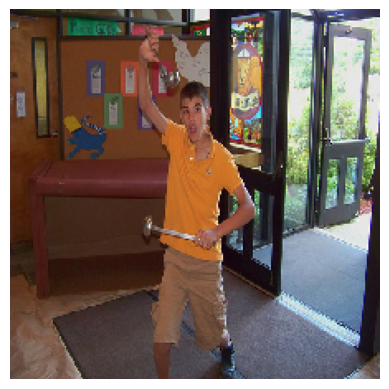

📝 Wygenerowany opis:
two men with swimming are in a wall of a park


In [ ]:
test_img = sample_images[1]

img = image.load_img(os.path.join(IMAGE_DIR, test_img), target_size=(224,224))
plt.imshow(img)
plt.axis("off")
plt.show()

print("📝 Wygenerowany opis:")
print(generate_caption(test_img))

As one can see, the description is not satisfactory. There might be few reasons why.
* Limited training data – sing only a subset of Flickr8k (e.g., MAX_SAMPLES = 5000) may prevent the model from learning rare words or diverse sentence structures.
* Simplified model architecture – the current model is relatively small, which may lead to it struggling with complex linguistic patterns or subtle relationships between image features and words.
* Loss of context during sequence modeling – predicting one word at a time can accumulate errors — if an early word is predicted incorrectly, the rest of the caption may also be incorrect.
* Feature abstraction limitations – the CNN provides high-level image embeddings, but some details (like small objects or complex scenes) may not be fully captured.

To better understand this model, the XAI is implemented below.

# **Explainable AI: Visualizing CNN Attention with Grad-CAM.**

XAI visualizes which regions of an image contribute most to the CNN features used by the captioning model. The following steps are implemented:
* Image preprocessing – *load_and_preprocess_image_for_cnn* resizes and prepares images for the MobileNetV2 CNN.
* Grad-CAM computation – *make_gradcam_heatmap* uses gradients of the predicted class with respect to the last convolutional layer to produce a heatmap showing important regions.


In [ ]:
def load_and_preprocess_image_for_cnn(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img

def make_gradcam_heatmap(img_tensor, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_tensor)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))


    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) == 0:
        return heatmap
    heatmap /= np.max(heatmap)
    return heatmap

* Visualization – for each sample image, the heatmap is overlaid on the original image, highlighting areas that strongly influence the CNN. The generated caption is displayed alongside, which allows inspection of the model’s reasoning.

Generating Grad-CAM visualizations for sample images...


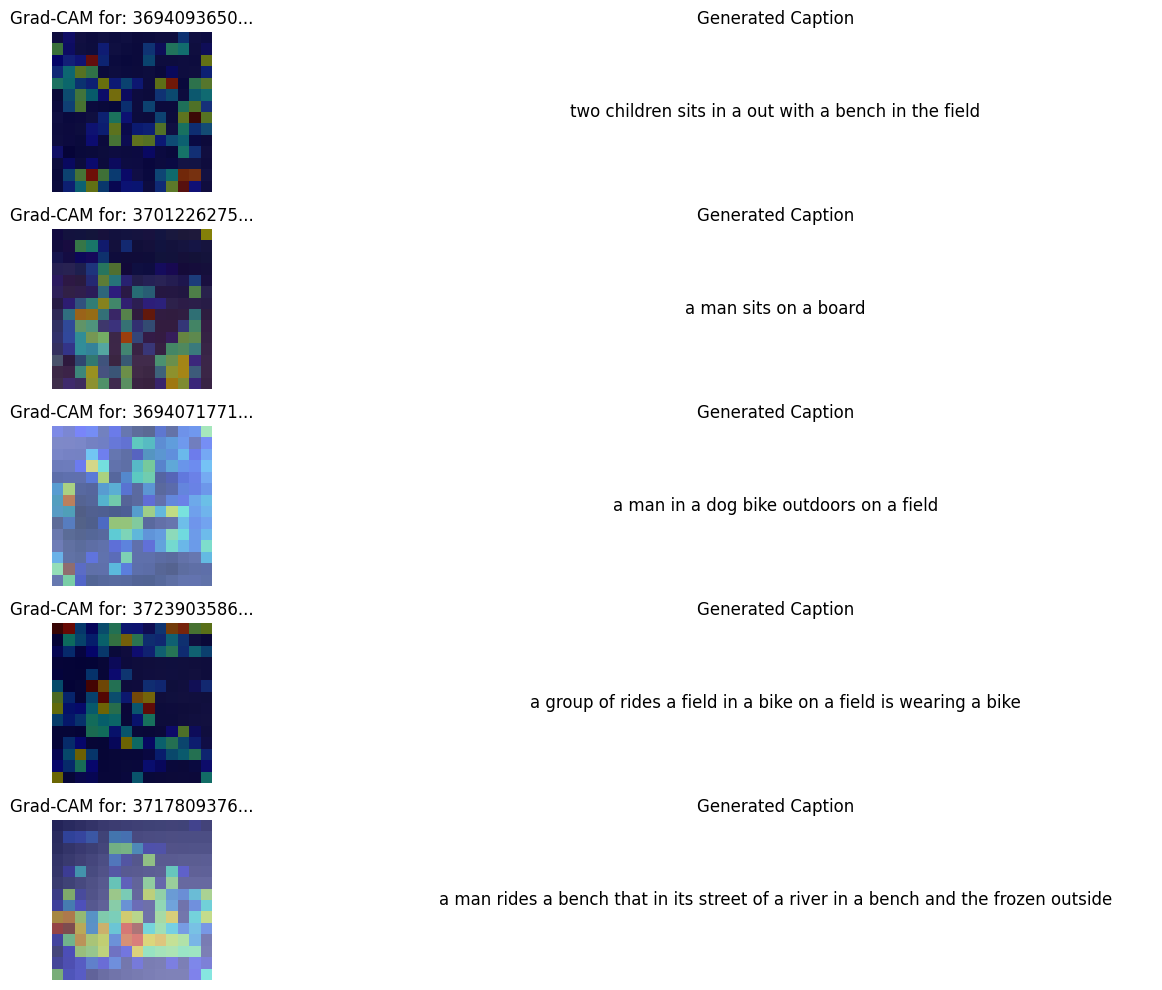

In [ ]:
print("Generating Grad-CAM visualizations for sample images...")

plt.figure(figsize=(15, 10))
for i, img_name in enumerate(sample_images):
    sample_img_path = os.path.join(IMAGE_DIR, img_name)
    sample_img_tensor = load_and_preprocess_image_for_cnn(sample_img_path)

    heatmap = make_gradcam_heatmap(sample_img_tensor, cnn, last_conv_layer_name="block_13_expand")

    img = image.load_img(sample_img_path, target_size=(224,224))

    plt.subplot(len(sample_images), 2, 2*i + 1)
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.axis("off")
    plt.title(f"Grad-CAM for: {img_name[:10]}...")

    caption = generate_caption(img_name)
    plt.subplot(len(sample_images), 2, 2*i + 2)
    plt.text(0.5, 0.5, caption, horizontalalignment='center', verticalalignment='center', fontsize=12, wrap=True)
    plt.axis("off")
    plt.title("Generated Caption")

plt.tight_layout()
plt.show()

# **Summary.**

This project successfully implemented an end-to-end image captioning system that combines a Convolutional Neural Network for visual feature extraction with a Long Short-Term Memory network for sequence generation. Using a pretrained MobileNetV2 model as a fixed feature extractor and training on a subset of the Flickr8k dataset, the model learned to map image content to natural language descriptions. The architecture merged 1280-dimensional visual features with embedded token sequences through a dual-branch design, ultimately predicting the next word in a caption via a softmax classifier. Throughout 15 epochs of training, the model demonstrated consistent loss reduction from **1.474** to **0.566,** confirming its ability to learn from the paired image-caption data.

Despite that, the generated captions revealed significant limitations. While the model occasionally captured relevant objects and actions, the outputs were often grammatically incorrect and semantically imprecise, as illustrated by the generated description: "two men with swimming are in a wall of a park." These shortcomings can be attributed to several factors, including the use limited training data, a relatively compact model architecture, and the inherent difficulty of aligning high-level visual features with fine-grained linguistic concepts. Additionally, the iterative nature of the decoding process makes the model susceptible to error propagation, where a single incorrect prediction early in the sequence can derail the remainder of the caption.

To better understand the model’s visual reasoning, Explainable AI techniques were integrated in the form of Grad-CAM heatmaps. These visualizations highlighted which regions of an input image were most influential in driving the CNN’s feature extraction.